**Load Dataset**

In [140]:
import pandas as pd

df = pd.read_csv('classifier_p90_labels.csv')

**Feature Selection**

In [141]:
X = df.drop(
    columns=[
        'label',
        'final_status',
        'timestep',
        'soil_sensor',
        'timestamp'
    ],
    errors='ignore'
)

y = df['label']
print(df['label'].value_counts())

label
0    8171
1     313
Name: count, dtype: int64


**Data Visualization**

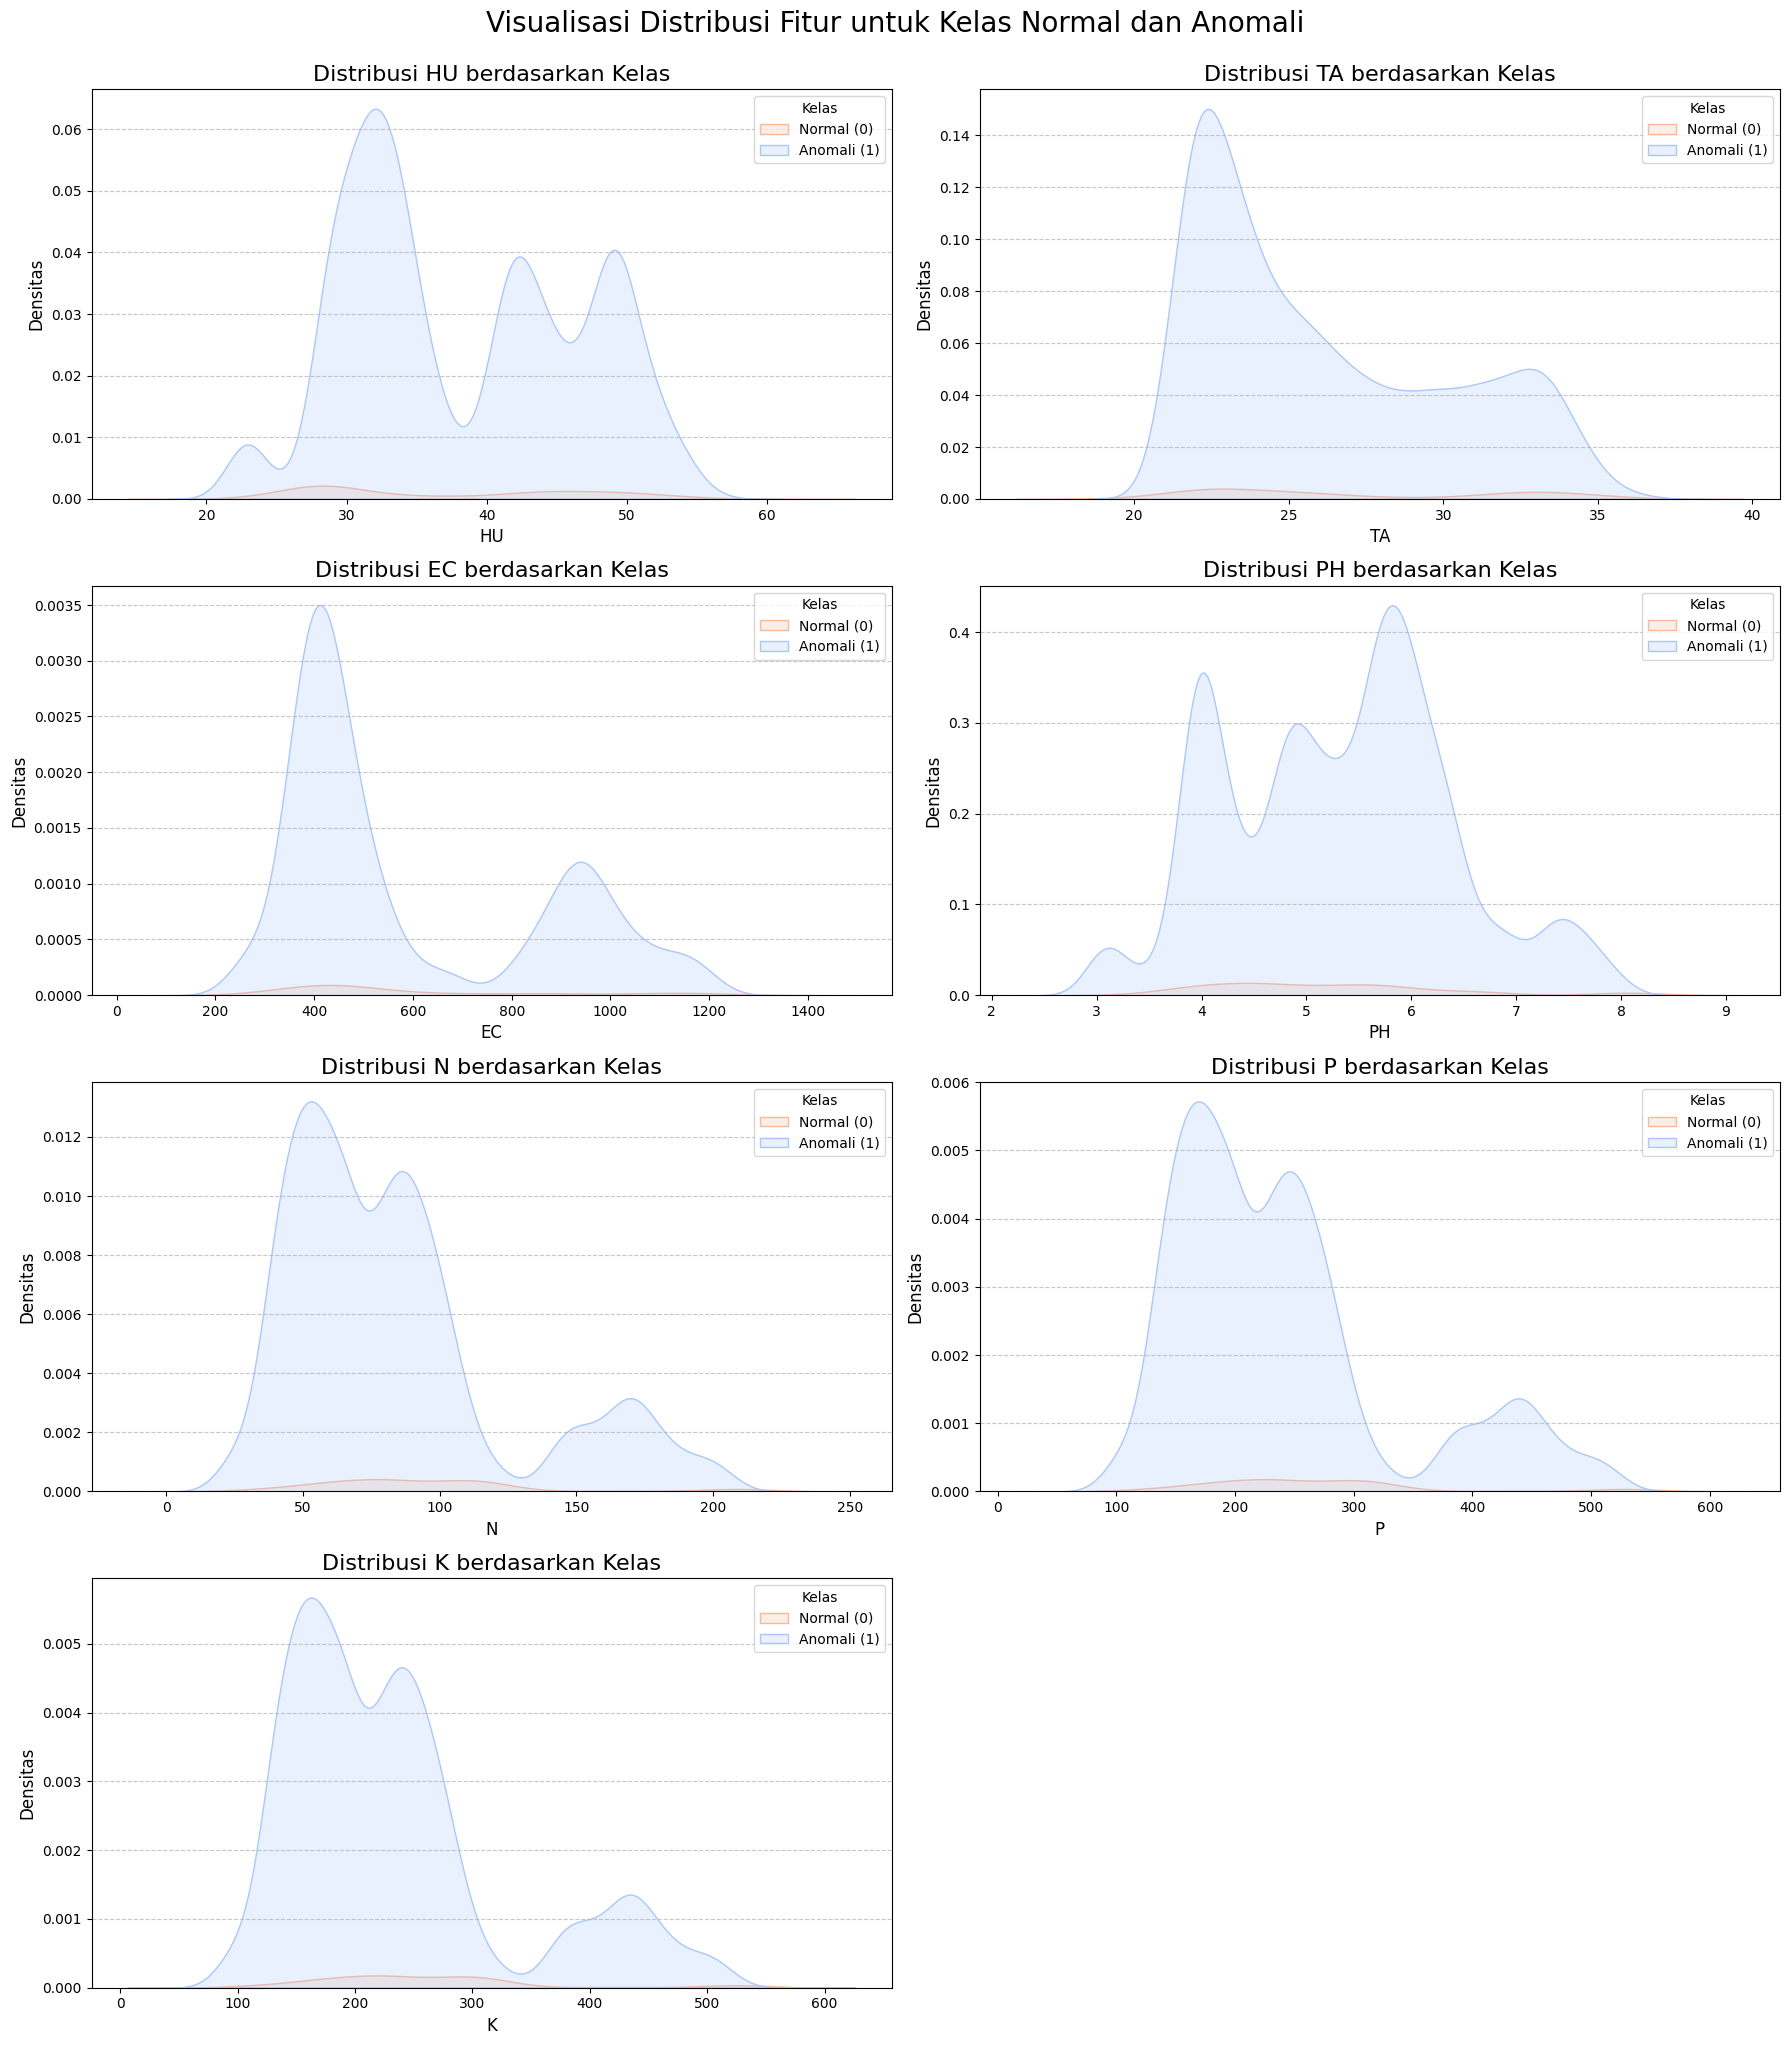

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gabungkan X dan y untuk plotting yang lebih mudah
df_plot = X.copy()
df_plot['label'] = y

features = X.columns # Dapatkan nama-nama fitur

# Buat subplot untuk setiap fitur
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten() # Ratakan array axes untuk iterasi mudah

# Loop melalui setiap fitur dan buat plot
for i, feature in enumerate(features):
    sns.kdeplot(
        data=df_plot,
        x=feature,
        hue='label',
        fill=True,
        ax=axes[i],
        palette='coolwarm' # Menggunakan palet warna yang berbeda
    )
    axes[i].set_title(f'Distribusi {feature.upper()} berdasarkan Kelas', fontsize=16)
    axes[i].set_xlabel(feature.upper(), fontsize=12)
    axes[i].set_ylabel('Densitas', fontsize=12)
    axes[i].legend(title='Kelas', labels=['Normal (0)', 'Anomali (1)']) # Menambahkan label kustom pada legend
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Menghapus subplot yang tidak digunakan jika jumlah fitur ganjil
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Visualisasi Distribusi Fitur untuk Kelas Normal dan Anomali', y=1.02, fontsize=20)
plt.show()

**Train-Test Split**

In [183]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTrain Label Distribution")
print(y_train.value_counts())

print("\nTest Label Distribution")
print(y_test.value_counts())

Train Shape: (6787, 7)
Test Shape : (1697, 7)

Train Label Distribution
label
0    6537
1     250
Name: count, dtype: int64

Test Label Distribution
label
0    1634
1      63
Name: count, dtype: int64


**SMOTE Oversampling**

In [184]:
# SMOTE hanya pada data training
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nSetelah SMOTE")
print("Train Shape:", X_train.shape)

print("\nTrain Label Distribution After SMOTE")
print(y_train.value_counts())


Setelah SMOTE
Train Shape: (13074, 7)

Train Label Distribution After SMOTE
label
0    6537
1    6537
Name: count, dtype: int64


**RANDOM FOREST**

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [145]:
rf_pred = rf.predict(X_test)

In [146]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9781968179139658

Confusion Matrix
[[1607   27]
 [  10   53]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1634
           1       0.66      0.84      0.74        63

    accuracy                           0.98      1697
   macro avg       0.83      0.91      0.86      1697
weighted avg       0.98      0.98      0.98      1697



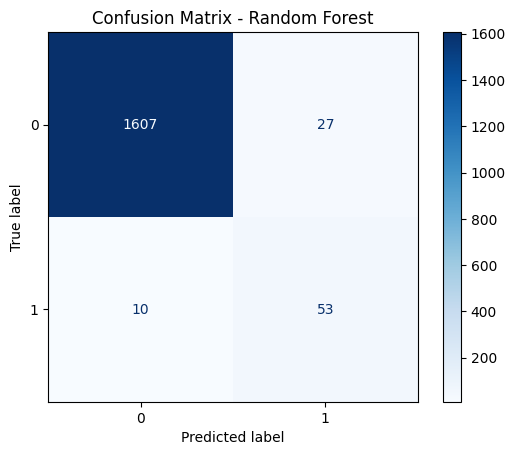

In [147]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

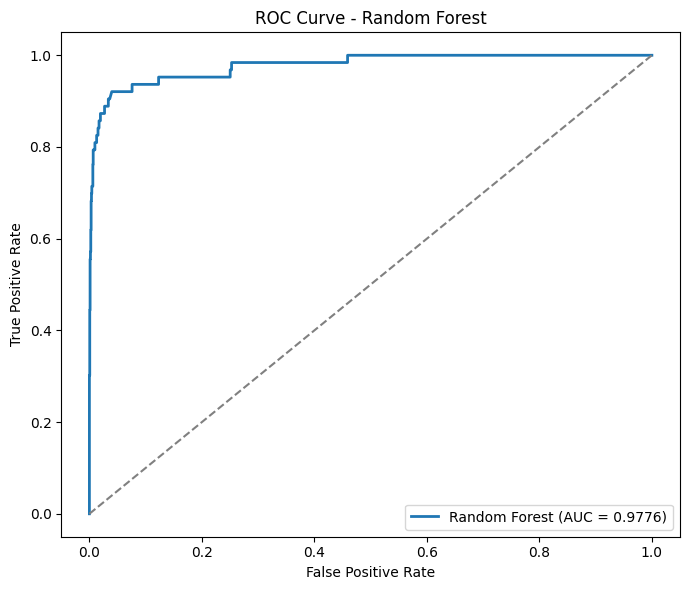

In [148]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilitas
rf_prob = rf.predict_proba(X_test)[:, 1]

# ROC-AUC
rf_auc = roc_auc_score(y_test, rf_prob)

# ROC Curve
rf_fpr, rf_tpr, rf_threshold = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**SUPPORT VECTOR MACHINE**

In [149]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [150]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    # class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [151]:
svm_pred = svm.predict(X_test_scaled)

In [152]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

Accuracy: 0.9210371243370654

Confusion Matrix
[[1507  127]
 [   7   56]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1634
           1       0.31      0.89      0.46        63

    accuracy                           0.92      1697
   macro avg       0.65      0.91      0.71      1697
weighted avg       0.97      0.92      0.94      1697



In [153]:
svm_prob = svm.predict_proba(X_test_scaled)[:,1]
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"SVM ROC-AUC: {svm_auc:.4f}")

SVM ROC-AUC: 0.9552


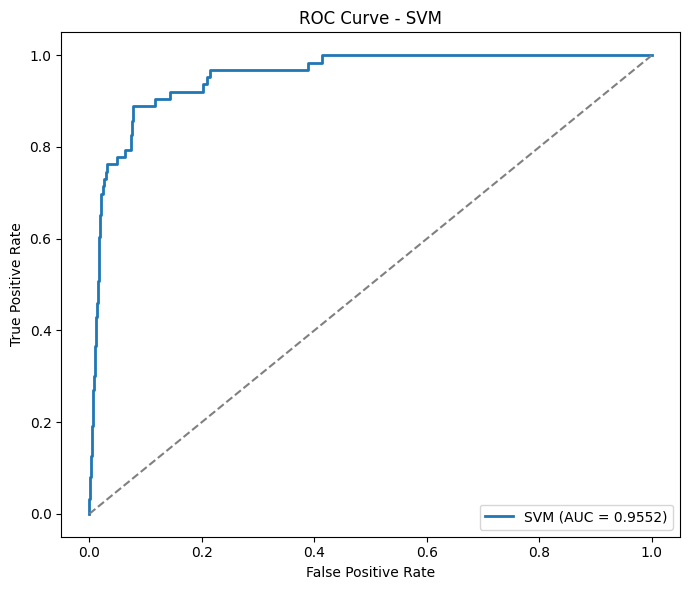

In [154]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

svm_prob = svm.predict_proba(X_test_scaled)[:,1]

svm_auc = roc_auc_score(
    y_test,
    svm_prob
)

svm_fpr, svm_tpr, svm_threshold = roc_curve(
    y_test,
    svm_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f'SVM (AUC = {svm_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**K-nearestNeighbour**

In [155]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='manhattan'
)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='manhattan', weights='distance')

In [156]:
knn_pred = knn.predict(X_test_scaled)

In [157]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

Accuracy: 0.9829110194460813

Confusion Matrix
[[1614   20]
 [   9   54]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1634
           1       0.73      0.86      0.79        63

    accuracy                           0.98      1697
   macro avg       0.86      0.92      0.89      1697
weighted avg       0.98      0.98      0.98      1697



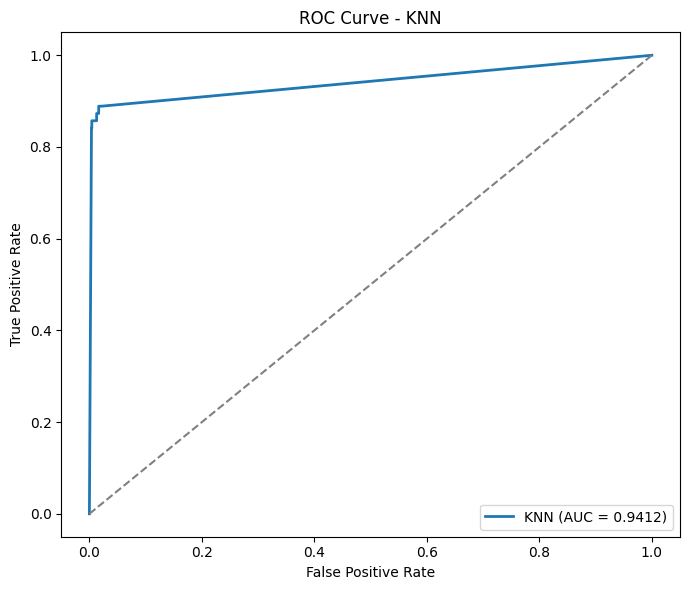

In [158]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

knn_prob = knn.predict_proba(X_test_scaled)[:,1]

knn_auc = roc_auc_score(
    y_test,
    knn_prob
)

knn_fpr, knn_tpr, knn_threshold = roc_curve(
    y_test,
    knn_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    knn_fpr,
    knn_tpr,
    linewidth=2,
    label=f'KNN (AUC = {knn_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Decision Tree**

In [159]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    # class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [160]:
dt_pred = dt.predict(X_test)

In [161]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy: 0.9469652327637006

Confusion Matrix
[[1559   75]
 [  15   48]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1634
           1       0.39      0.76      0.52        63

    accuracy                           0.95      1697
   macro avg       0.69      0.86      0.74      1697
weighted avg       0.97      0.95      0.96      1697



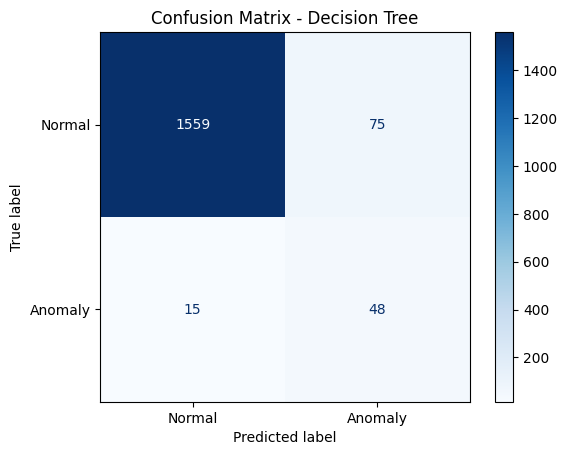

In [162]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal','Anomaly']
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

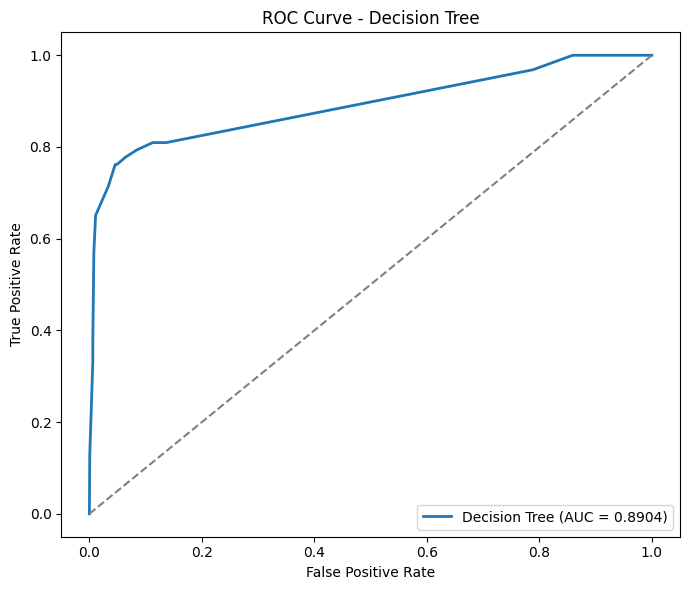

In [163]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

dt_prob = dt.predict_proba(X_test)[:,1]

dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

dt_fpr, dt_tpr, dt_threshold = roc_curve(
    y_test,
    dt_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=2,
    label=f'Decision Tree (AUC = {dt_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**XGBoost**

In [164]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [165]:
xgb_pred = xgb.predict(X_test)

In [166]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.9369475545079552

Confusion Matrix
[[1540   94]
 [  13   50]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1634
           1       0.35      0.79      0.48        63

    accuracy                           0.94      1697
   macro avg       0.67      0.87      0.72      1697
weighted avg       0.97      0.94      0.95      1697



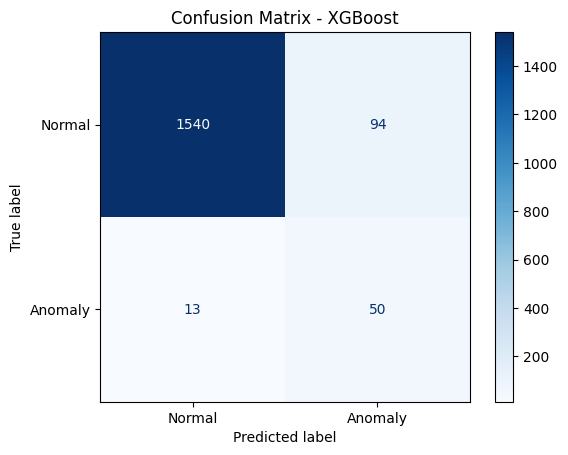

In [167]:
cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal','Anomaly']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

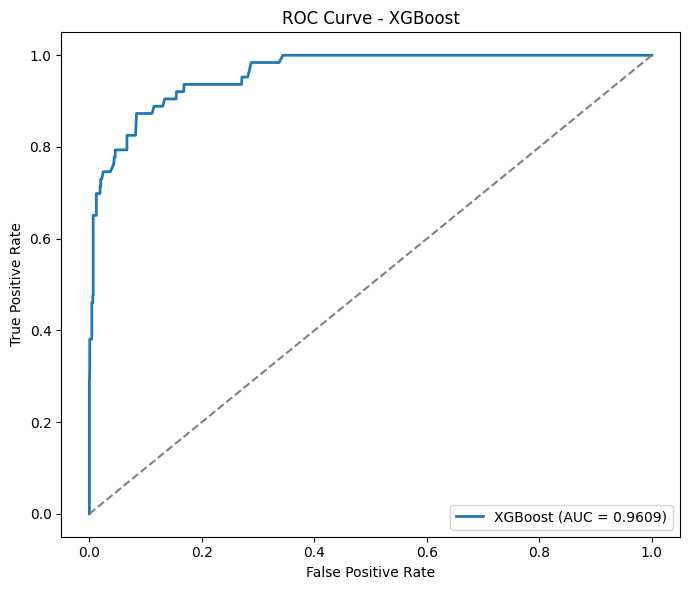

In [168]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

xgb_prob = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_fpr, xgb_tpr, xgb_threshold = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f'XGBoost (AUC = {xgb_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Model Comparison**

In [169]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = [
    ("Random Forest", rf, X_test),
    ("SVM", svm, X_test_scaled),
    ("KNN", knn, X_test_scaled),
    ("Decision Tree", dt, X_test),
    ("XGBoost", xgb, X_test)
]

for name, model, X_eval in models:

    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None

    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision (%)": round(precision_score(y_test, y_pred, pos_label=1, zero_division=0) * 100, 2),
        "Recall (%)": round(recall_score(y_test, y_pred, pos_label=1, zero_division=0) * 100, 2),
        "F1-Score (%)": round(f1_score(y_test, y_pred, pos_label=1, zero_division=0) * 100, 2),
        "ROC-AUC (%)": round(auc * 100, 2) if auc is not None else None
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-Score (%)",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,KNN,98.29,72.97,85.71,78.83,94.12
1,Random Forest,97.82,66.25,84.13,74.13,97.76
2,Decision Tree,94.70,39.02,76.19,51.61,89.04
3,XGBoost,93.69,34.72,79.37,48.31,96.09
4,SVM,92.10,30.60,88.89,45.53,95.52


**Cross Validation**

In [170]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# Stratified 5-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
scores = cross_validate(
    estimator=knn,
    X=X_train_scaled,
    y=y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc'
    ],
    n_jobs=-1
)

# Menampilkan hasil tiap fold
for i in range(5):
    print(f"""
Fold {i+1}
Accuracy : {scores['test_accuracy'][i]*100:.2f}%
Precision: {scores['test_precision'][i]*100:.2f}%
Recall   : {scores['test_recall'][i]*100:.2f}%
F1-Score : {scores['test_f1'][i]*100:.2f}%
ROC-AUC  : {scores['test_roc_auc'][i]*100:.2f}%
""")

# Rata-rata hasil
cv_result = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
    'Mean (%)': [
        scores['test_accuracy'].mean()*100,
        scores['test_precision'].mean()*100,
        scores['test_recall'].mean()*100,
        scores['test_f1'].mean()*100,
        scores['test_roc_auc'].mean()*100
    ],
    'Std (%)': [
        scores['test_accuracy'].std()*100,
        scores['test_precision'].std()*100,
        scores['test_recall'].std()*100,
        scores['test_f1'].std()*100,
        scores['test_roc_auc'].std()*100
    ]
})

cv_result['Mean (%)'] = cv_result['Mean (%)'].round(2)
cv_result['Std (%)'] = cv_result['Std (%)'].round(2)

display(cv_result)


Fold 1
Accuracy : 99.20%
Precision: 98.79%
Recall   : 99.62%
F1-Score : 99.20%
ROC-AUC  : 99.72%


Fold 2
Accuracy : 99.20%
Precision: 98.42%
Recall   : 100.00%
F1-Score : 99.20%
ROC-AUC  : 99.72%


Fold 3
Accuracy : 99.43%
Precision: 98.94%
Recall   : 99.92%
F1-Score : 99.43%
ROC-AUC  : 99.84%


Fold 4
Accuracy : 99.04%
Precision: 98.42%
Recall   : 99.69%
F1-Score : 99.05%
ROC-AUC  : 99.56%


Fold 5
Accuracy : 99.31%
Precision: 99.01%
Recall   : 99.62%
F1-Score : 99.31%
ROC-AUC  : 99.72%



,Metric,Mean (%),Std (%)
0,Accuracy,99.24,0.13
1,Precision,98.71,0.25
2,Recall,99.77,0.16
3,F1-Score,99.24,0.13
4,ROC-AUC,99.71,0.09


**CV Visualization**

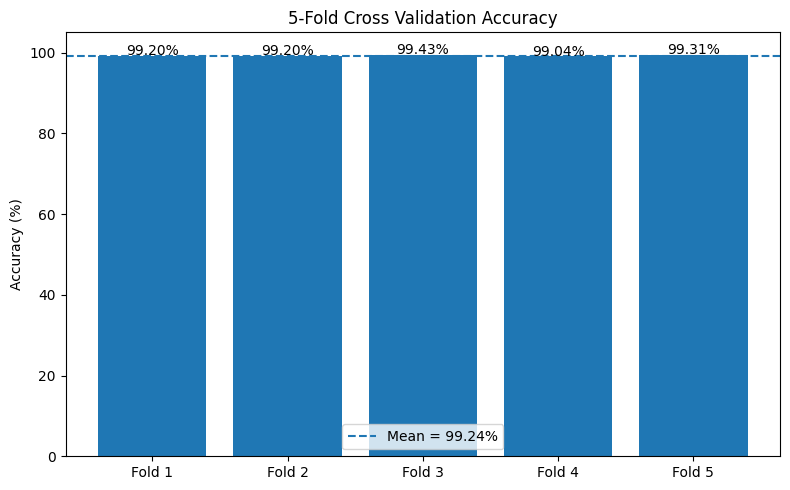

In [171]:
import matplotlib.pyplot as plt
import numpy as np

folds = [f'Fold {i}' for i in range(1, 6)]

# Extract accuracy and F1 scores from the 'scores' dictionary
accuracy_scores = scores['test_accuracy']
f1_scores = scores['test_f1']

# ==========================
# Accuracy
# ==========================
plt.figure(figsize=(8,5))

bars = plt.bar(folds, accuracy_scores * 100)

plt.title('5-Fold Cross Validation Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.axhline(
    np.mean(accuracy_scores) * 100,
    linestyle='--',
    label=f'Mean = {np.mean(accuracy_scores)*100:.2f}%'
)
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f'{height:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

**Overfitting Analysis**

In [172]:
from sklearn.metrics import accuracy_score, f1_score

# Training performance
y_train_pred = knn.predict(X_train_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Testing performance
y_test_pred = knn.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print(f"\nTrain F1-Score : {train_f1:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")

Train Accuracy : 0.9998
Test Accuracy  : 0.9829

Train F1-Score : 0.9998
Test F1-Score  : 0.7883


In [173]:
import numpy as np
import pandas as pd

# Mean CV
cv_acc_mean = np.mean(scores['test_accuracy'])
cv_f1_mean = np.mean(scores['test_f1'])

# Gap
gap_acc_train_test = abs(train_acc - test_acc)
gap_acc_train_cv = abs(train_acc - cv_acc_mean)

gap_f1_train_test = abs(train_f1 - test_f1)
gap_f1_train_cv = abs(train_f1 - cv_f1_mean)

# Ringkasan
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score'],
    'Train': [train_acc*100, train_f1*100],
    'CV Mean': [cv_acc_mean*100, cv_f1_mean*100],
    'Test': [test_acc*100, test_f1*100],
    'Gap Train-CV': [gap_acc_train_cv*100, gap_f1_train_cv*100],
    'Gap Train-Test': [gap_acc_train_test*100, gap_f1_train_test*100]
})

print(summary.round(2))

     Metric  Train  CV Mean   Test  Gap Train-CV  Gap Train-Test
0  Accuracy  99.98    99.24  98.29          0.75            1.69
1  F1-Score  99.98    99.24  78.83          0.75           21.15


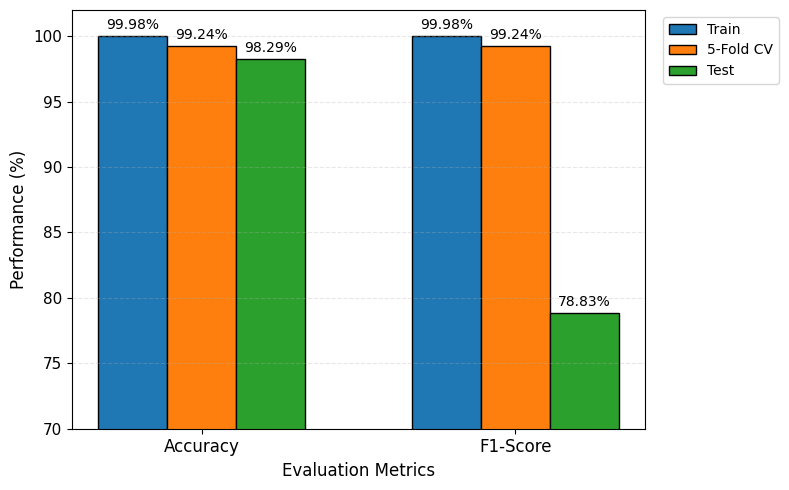

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['Accuracy', 'F1-Score']

train = [train_acc * 100, train_f1 * 100]
cv = [cv_acc_mean * 100, cv_f1_mean * 100]
test = [test_acc * 100, test_f1 * 100]

x = np.arange(len(metrics))
width = 0.22

plt.figure(figsize=(8, 5))

# Bar chart
bars1 = plt.bar(
    x - width,
    train,
    width,
    label='Train',
    edgecolor='black'
)

bars2 = plt.bar(
    x,
    cv,
    width,
    label='5-Fold CV',
    edgecolor='black'
)

bars3 = plt.bar(
    x + width,
    test,
    width,
    label='Test',
    edgecolor='black'
)


# Label nilai
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.3,
            f'{height:.2f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )


# Axis
plt.xticks(
    x,
    metrics,
    fontsize=12
)

plt.yticks(
    fontsize=11
)

plt.ylabel(
    'Performance (%)',
    fontsize=12
)

plt.xlabel(
    'Evaluation Metrics',
    fontsize=12
)


# Jangan terlalu zoom
plt.ylim(70, 102)


# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# Legend keluar area grafik
plt.legend(
    fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)


plt.tight_layout()

plt.savefig(
    "perbandingan_train_cv_test.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

**SHAP**

In [175]:
pip install shap

In [176]:
y_pred = knn.predict(X_test_scaled)

import numpy as np
import pandas as pd
import shap

# Ambil data yang diprediksi anomali
anomaly_idx = np.where(y_pred == 1)[0]

X_anomaly = X_test_scaled[anomaly_idx]

print("Jumlah data anomali:", len(X_anomaly))

Jumlah data anomali: 74


In [177]:
# Background sample
background = shap.sample(
    X_train_scaled,
    100,
    random_state=42
)

# SHAP Explainer
explainer = shap.KernelExplainer(
    knn.predict_proba,
    background
)

# SHAP values hanya untuk data anomali
shap_values = explainer.shap_values(X_anomaly)

  0%|          | 0/74 [00:00<?, ?it/s]

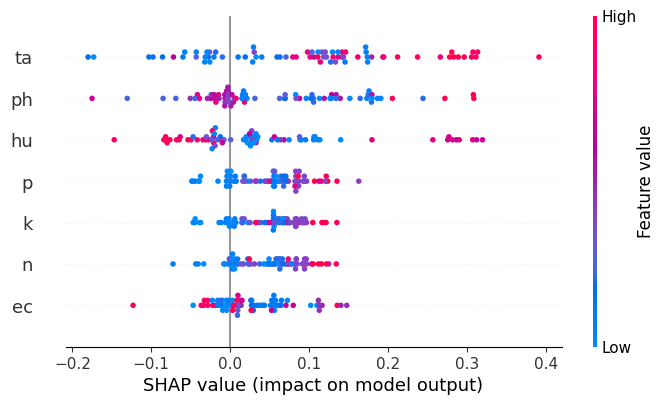

In [178]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[:, :, 1],
        data=X_anomaly,
        feature_names=X.columns
    ),
    max_display=len(X.columns)
)

In [179]:
# Mean Absolute SHAP kelas anomali (class=1)
mean_shap = np.abs(
    shap_values[:, :, 1]
).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_shap
})

importance_df = importance_df.sort_values(
    by='Mean |SHAP|',
    ascending=False
)

print(importance_df)

  Feature  Mean |SHAP|
1      ta     0.129883
3      ph     0.083471
0      hu     0.080365
5       p     0.056542
6       k     0.054252
4       n     0.053856
2      ec     0.041294


**Feature Importance**

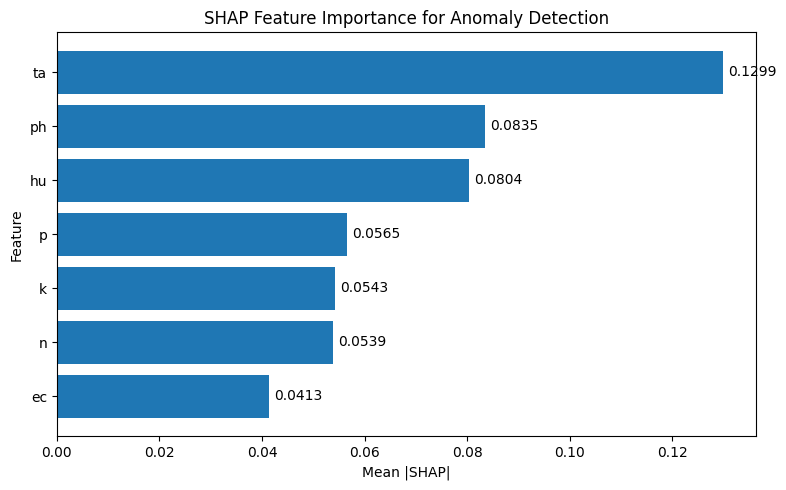

In [180]:
import matplotlib.pyplot as plt

plot_df = importance_df.sort_values(
    by='Mean |SHAP|',
    ascending=True
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    plot_df['Feature'],
    plot_df['Mean |SHAP|']
)

plt.xlabel('Mean |SHAP|')
plt.ylabel('Feature')
plt.title('Feature Importance for Anomaly Detection')

# Nilai di ujung batang
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{value:.4f}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [181]:
import joblib

joblib.dump(knn, "knn_model.pkl")
joblib.dump(scaler, "knn_scaler.pkl")

print("Model dan scaler berhasil disimpan.")

Model dan scaler berhasil disimpan.


In [182]:
import pandas as pd

# Prepare results for each model
results_data = {
    'KNN': pd.DataFrame({'Actual': y_test, 'Predicted': knn_pred}),
    'SVM': pd.DataFrame({'Actual': y_test, 'Predicted': svm_pred}),
    'Random Forest': pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred}),
    'Decision Tree': pd.DataFrame({'Actual': y_test, 'Predicted': dt_pred}),
    'XGBoost': pd.DataFrame({'Actual': y_test, 'Predicted': xgb_pred})
}

# Nama file Excel
excel_file_name = 'classification_results.xlsx'

# Simpan ke Excel
with pd.ExcelWriter(excel_file_name, engine='xlsxwriter') as writer:
    for sheet_name, df_results in results_data.items():
        df_results.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Hasil klasifikasi telah tersimpan di '{excel_file_name}' pada storage sementara Colab.")

Hasil klasifikasi telah tersimpan di 'classification_results.xlsx' pada storage sementara Colab.
